In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

In [2]:
X, y = make_classification(
    n_samples=1200,
    n_features=8,
    n_informative=5,
    n_redundant=1,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    class_sep=1.5,
    flip_y=0.03,
    random_state=42
)

feature_names = [
    "Feature_1",
    "Feature_2",
    "Feature_3",
    "Feature_4",
    "Feature_5",
    "Feature_6",
    "Feature_7",
    "Feature_8"
]

df = pd.DataFrame(X, columns=feature_names)
df["Target"] = y

df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Target
0,-1.069753,1.499243,1.542256,-1.449599,0.788292,-1.008133,1.056101,0.826794,1
1,3.135086,1.364212,1.217375,2.849667,-0.039162,-1.953994,0.365394,2.795972,0
2,1.342511,-0.718524,1.346310,1.527532,-2.106889,0.750419,-0.837406,-2.534669,1
3,-3.079760,-0.804173,1.775472,0.847804,1.030919,-0.713602,-0.312836,1.927708,1
4,-1.099457,3.733007,2.765590,-2.949227,0.444854,-2.507839,-1.443926,2.199367,1


In [3]:
print("Dataset Shape:", df.shape)
print("\nTarget Distribution:")
print(df["Target"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum().sum())

Dataset Shape: (1200, 9)

Target Distribution:
Target
0    602
1    598
Name: count, dtype: int64

Missing Values:
0


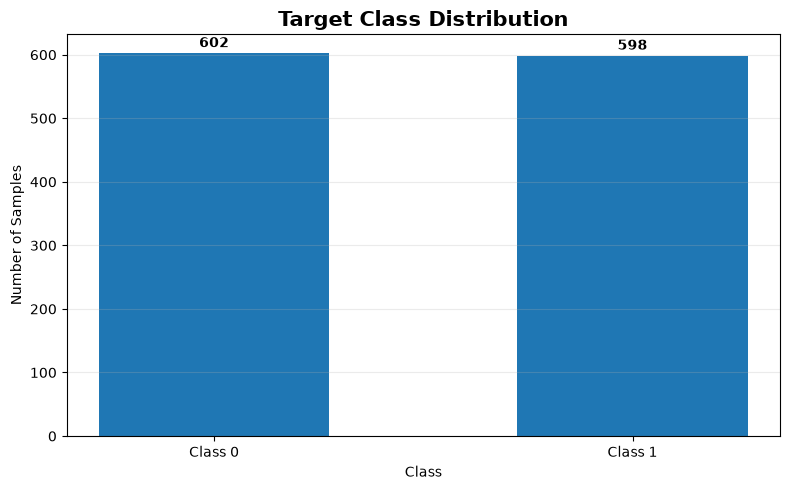

In [4]:
plt.figure(figsize=(8, 5))

counts = df["Target"].value_counts().sort_index()

bars = plt.bar(
    ["Class 0", "Class 1"],
    counts.values,
    width=0.55
)

plt.title("Target Class Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 10,
        str(value),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

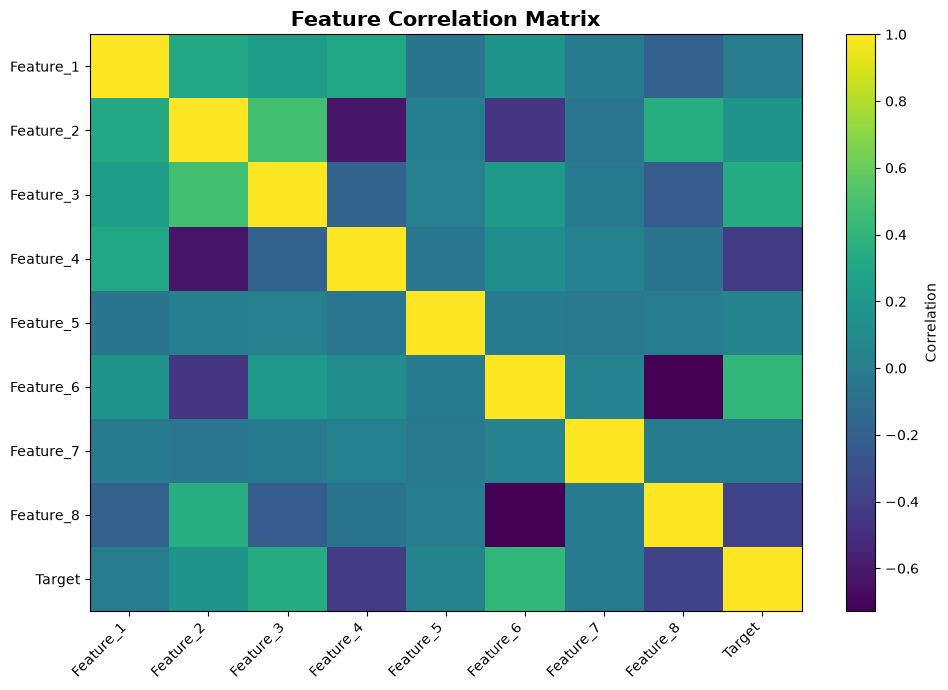

In [5]:
plt.figure(figsize=(10, 7))

correlation = df.corr(numeric_only=True)

plt.imshow(correlation, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Feature Correlation Matrix", fontsize=15, fontweight="bold")

plt.tight_layout()
plt.show()

In [6]:
X = df.drop("Target", axis=1)
y = df["Target"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1200, 8)
y Shape: (1200,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples: 960
Testing Samples : 240


In [19]:
stump = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

stump.fit(X_train, y_train)

stump_pred = stump.predict(X_test)

stump_accuracy = accuracy_score(y_test, stump_pred)

print("Decision Stump Accuracy:", round(stump_accuracy, 4))

Decision Stump Accuracy: 0.7417


In [20]:
stump = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

stump.fit(X_train, y_train)

stump_pred = stump.predict(X_test)

stump_accuracy = accuracy_score(y_test, stump_pred)

print("Decision Stump Accuracy:", round(stump_accuracy, 4))

Decision Stump Accuracy: 0.7417


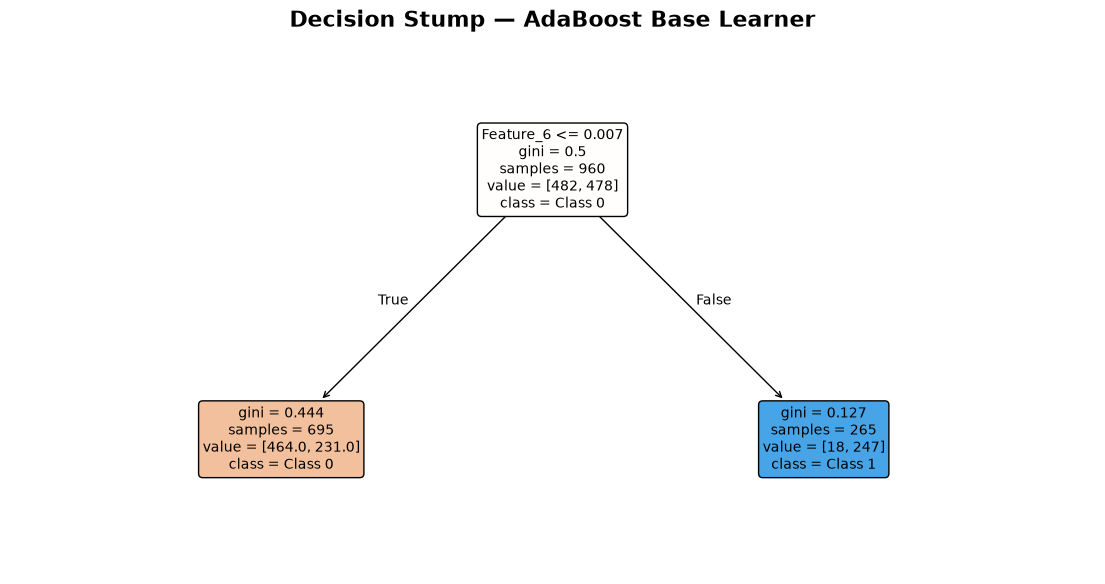

In [21]:
plt.figure(figsize=(14, 7))

plot_tree(
    stump,
    feature_names=X.columns,
    class_names=["Class 0", "Class 1"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title(
    "Decision Stump — AdaBoost Base Learner",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [22]:
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_model.fit(X_train, y_train)

y_pred = ada_model.predict(X_test)
y_prob = ada_model.predict_proba(X_test)[:, 1]

print("AdaBoost model trained successfully.")

AdaBoost model trained successfully.


In [23]:
accuracy = accuracy_score(y_test, y_pred)

print(f"AdaBoost Test Accuracy: {accuracy:.4f}")

AdaBoost Test Accuracy: 0.8958


In [24]:
print("AdaBoost Classification Report\n")
print(classification_report(y_test, y_pred))

AdaBoost Classification Report

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       120
           1       0.92      0.87      0.89       120

    accuracy                           0.90       240
   macro avg       0.90      0.90      0.90       240
weighted avg       0.90      0.90      0.90       240



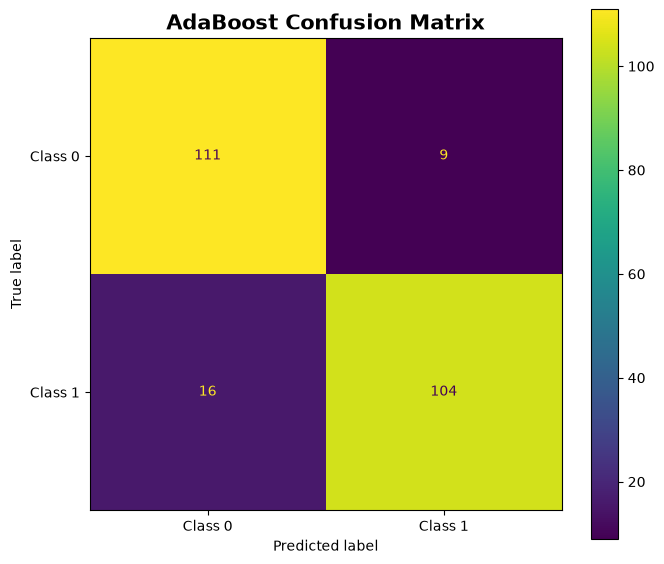

In [25]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "AdaBoost Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [26]:
auc_score = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.9670


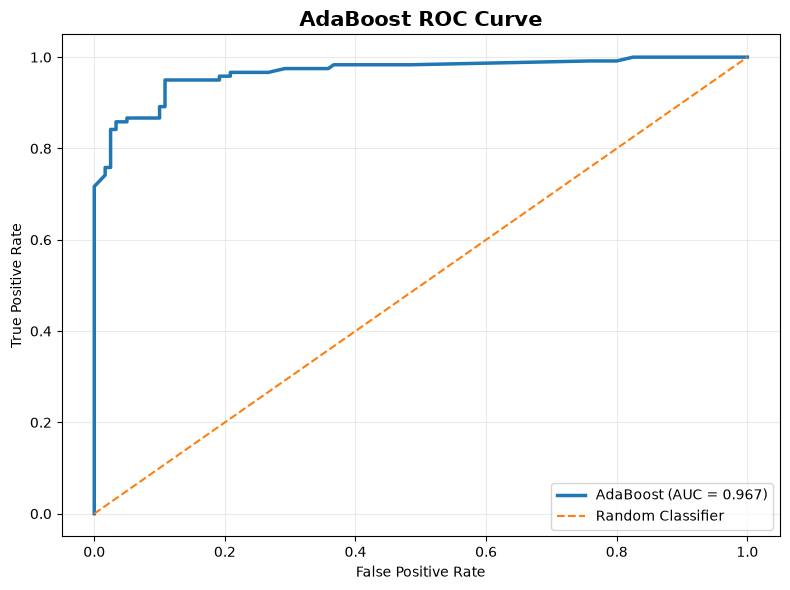

In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"AdaBoost (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "AdaBoost ROC Curve",
    fontsize=15,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [28]:
importance = pd.Series(
    ada_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

Feature_4    0.439737
Feature_6    0.224276
Feature_8    0.168325
Feature_3    0.090405
Feature_2    0.051013
Feature_1    0.026243
Feature_5    0.000000
Feature_7    0.000000
dtype: float64

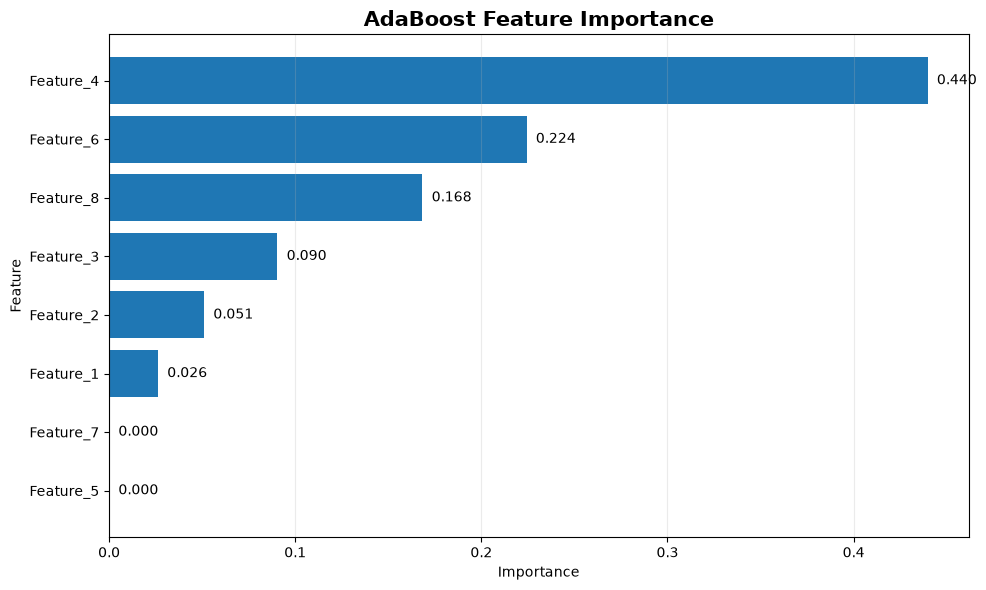

In [29]:
importance_sorted = importance.sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(
    importance_sorted.index,
    importance_sorted.values
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "AdaBoost Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.25)

for bar, value in zip(bars, importance_sorted.values):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

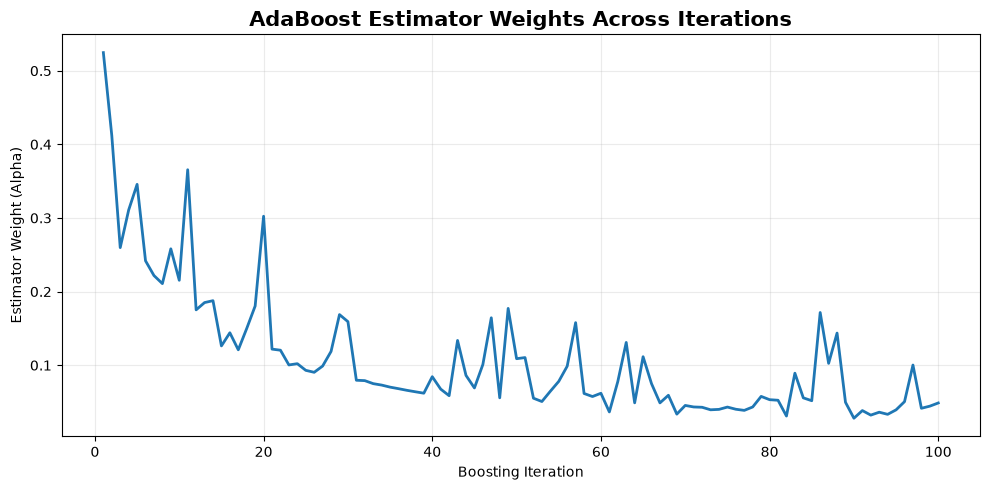

In [30]:
estimator_weights = ada_model.estimator_weights_

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(estimator_weights) + 1),
    estimator_weights,
    linewidth=2
)

plt.xlabel("Boosting Iteration")
plt.ylabel("Estimator Weight (Alpha)")

plt.title(
    "AdaBoost Estimator Weights Across Iterations",
    fontsize=15,
    fontweight="bold"
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

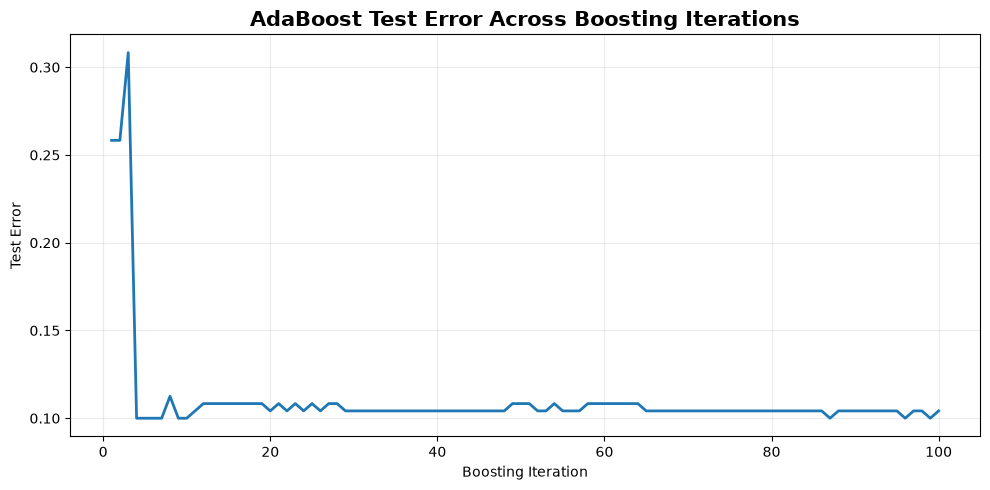

In [31]:
staged_errors = []

for pred in ada_model.staged_predict(X_test):
    staged_errors.append(
        1 - accuracy_score(y_test, pred)
    )

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(staged_errors) + 1),
    staged_errors,
    linewidth=2
)

plt.xlabel("Boosting Iteration")
plt.ylabel("Test Error")

plt.title(
    "AdaBoost Test Error Across Boosting Iterations",
    fontsize=15,
    fontweight="bold"
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [32]:
estimator_values = [10, 25, 50, 100, 150, 200]

accuracy_values = []

for n in estimator_values:

    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=1,
            random_state=42
        ),
        n_estimators=n,
        learning_rate=0.5,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy_values.append(
        accuracy_score(y_test, pred)
    )

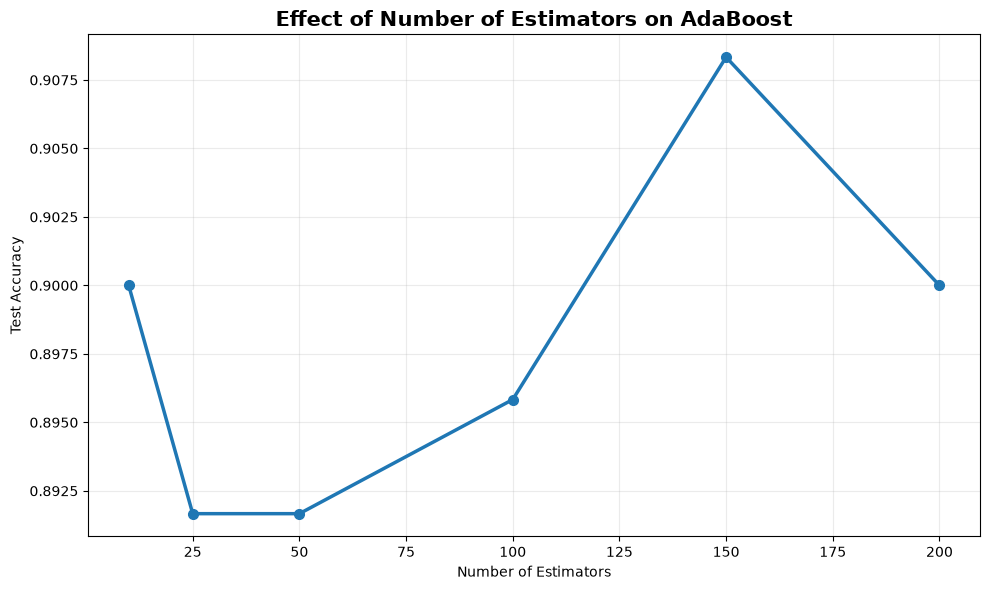

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    estimator_values,
    accuracy_values,
    marker="o",
    linewidth=2.5,
    markersize=7
)

plt.xlabel("Number of Estimators")
plt.ylabel("Test Accuracy")

plt.title(
    "Effect of Number of Estimators on AdaBoost",
    fontsize=15,
    fontweight="bold"
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [34]:
learning_rates = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]

lr_accuracy = []

for lr in learning_rates:

    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=1,
            random_state=42
        ),
        n_estimators=100,
        learning_rate=lr,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    lr_accuracy.append(
        accuracy_score(y_test, pred)
    )

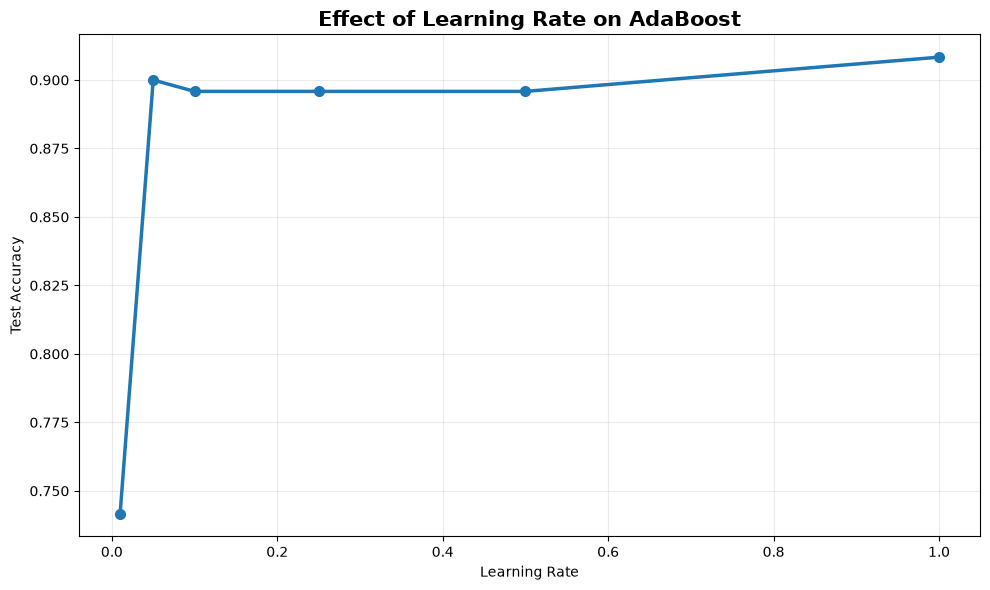

In [35]:
plt.figure(figsize=(10, 6))

plt.plot(
    learning_rates,
    lr_accuracy,
    marker="o",
    linewidth=2.5,
    markersize=7
)

plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")

plt.title(
    "Effect of Learning Rate on AdaBoost",
    fontsize=15,
    fontweight="bold"
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [36]:
base_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    random_state=42
)

param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.05, 0.1, 0.5, 1.0],
    "estimator__max_depth": [1, 2]
}

grid_search = GridSearchCV(
    estimator=base_ada,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__max_depth': [1, 2], 'learning_rate': [0.05, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them

In [37]:
base_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    random_state=42
)

param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.05, 0.1, 0.5, 1.0],
    "estimator__max_depth": [1, 2]
}

grid_search = GridSearchCV(
    estimator=base_ada,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__max_depth': [1, 2], 'learning_rate': [0.05, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__max_depth': [1, 2], 'learning_rate': [0.05, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them

In [40]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'estimator__max_depth': 2, 'learning_rate': 1.0, 'n_estimators': 150}

Best Cross-Validation Accuracy:
0.925


In [41]:
best_ada = grid_search.best_estimator_

best_pred = best_ada.predict(X_test)
best_prob = best_ada.predict_proba(X_test)[:, 1]

best_accuracy = accuracy_score(
    y_test,
    best_pred
)

best_auc = roc_auc_score(
    y_test,
    best_prob
)

print(f"Best Model Test Accuracy: {best_accuracy:.4f}")
print(f"Best Model ROC-AUC:        {best_auc:.4f}")

Best Model Test Accuracy: 0.9375
Best Model ROC-AUC:        0.9752


In [42]:
print("Final Tuned AdaBoost Classification Report\n")

print(
    classification_report(
        y_test,
        best_pred
    )
)

Final Tuned AdaBoost Classification Report

              precision    recall  f1-score   support

           0       0.94      0.93      0.94       120
           1       0.93      0.94      0.94       120

    accuracy                           0.94       240
   macro avg       0.94      0.94      0.94       240
weighted avg       0.94      0.94      0.94       240



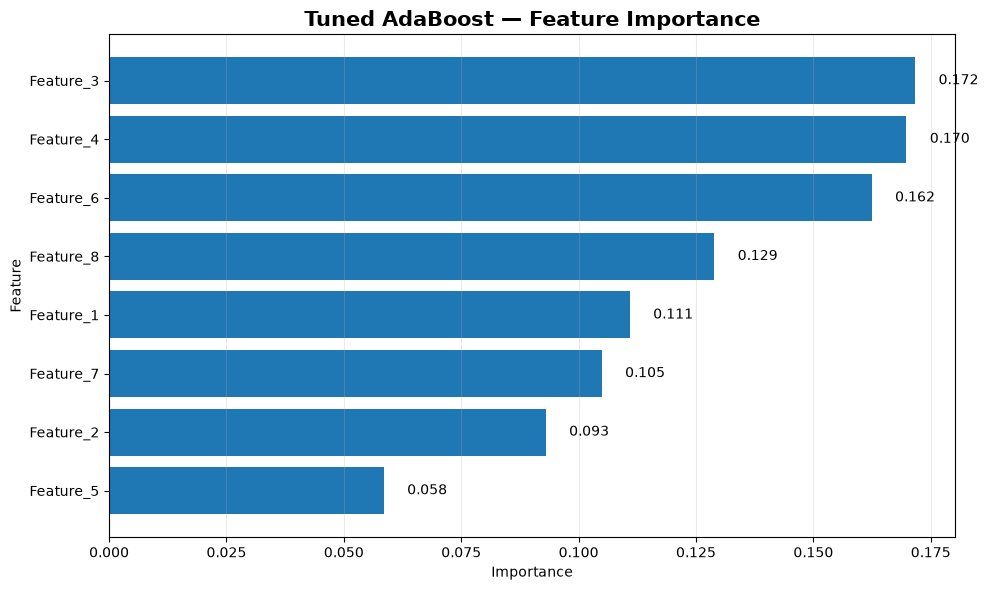

In [43]:
final_importance = pd.Series(
    best_ada.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    final_importance.index,
    final_importance.values
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Tuned AdaBoost — Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.25)

for bar, value in zip(
    bars,
    final_importance.values
):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [44]:
perm = permutation_importance(
    best_ada,
    X_test,
    y_test,
    n_repeats=15,
    random_state=42,
    scoring="accuracy"
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=True)

perm_importance

Feature_7   -0.006944
Feature_5   -0.000278
Feature_2    0.025000
Feature_8    0.040000
Feature_3    0.048056
Feature_1    0.072222
Feature_4    0.136944
Feature_6    0.153056
dtype: float64

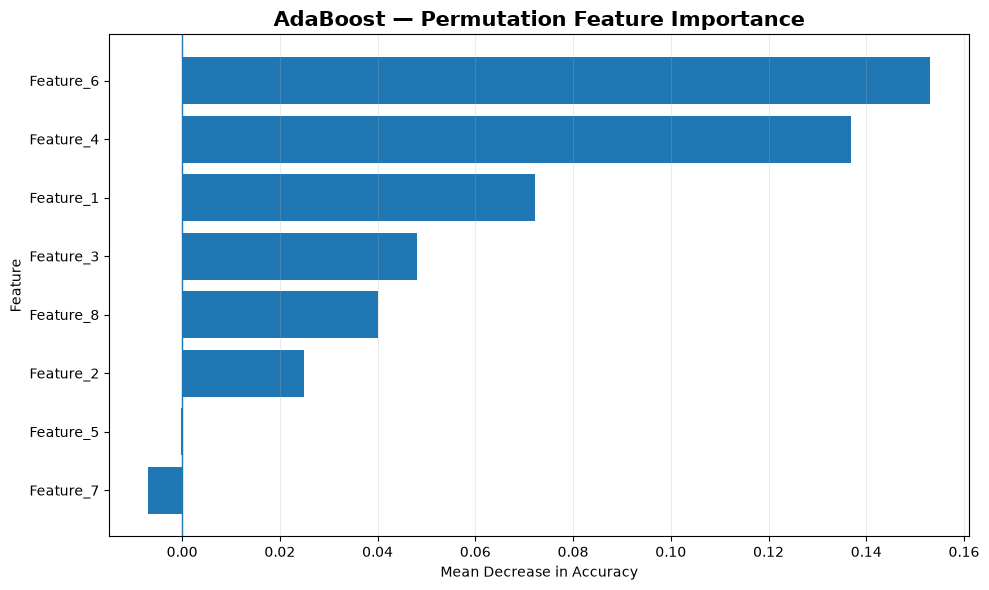

In [45]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    perm_importance.index,
    perm_importance.values
)

plt.xlabel("Mean Decrease in Accuracy")
plt.ylabel("Feature")

plt.title(
    "AdaBoost — Permutation Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.axvline(
    0,
    linewidth=1
)

plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

In [46]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

bagging_model.fit(X_train, y_train)

bagging_pred = bagging_model.predict(X_test)

bagging_accuracy = accuracy_score(
    y_test,
    bagging_pred
)

print(
    f"Bagging Accuracy: {bagging_accuracy:.4f}"
)
print(
    f"AdaBoost Accuracy: {accuracy:.4f}"
)

Bagging Accuracy: 0.7417
AdaBoost Accuracy: 0.8958


In [47]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Stump",
        "Bagging",
        "AdaBoost",
        "Tuned AdaBoost"
    ],
    "Accuracy": [
        stump_accuracy,
        bagging_accuracy,
        accuracy,
        best_accuracy
    ]
})

comparison

,Model,Accuracy
0,Decision Stump,0.741667
1,Bagging,0.741667
2,AdaBoost,0.895833
3,Tuned AdaBoost,0.937500


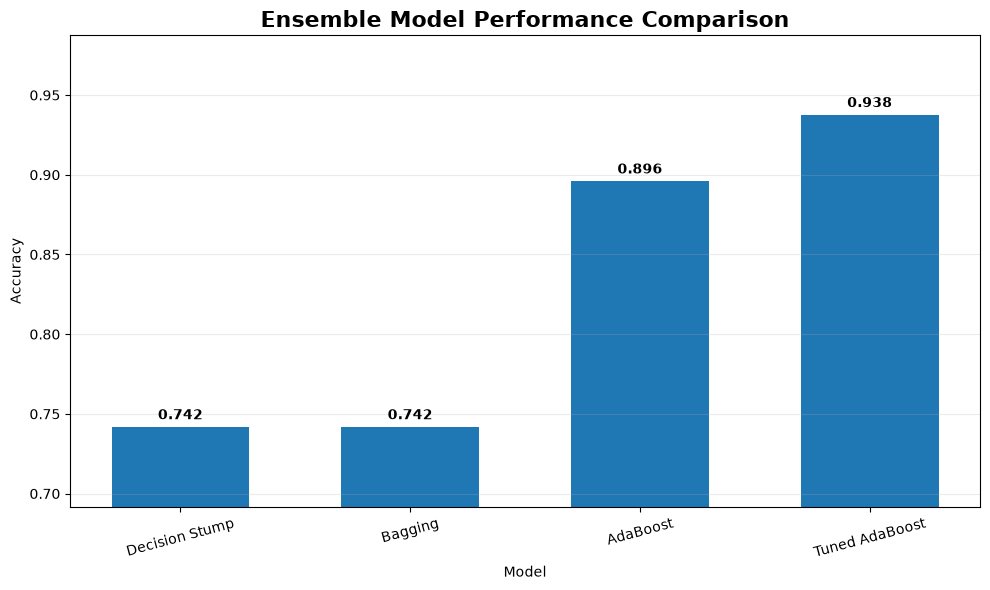

In [48]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    comparison["Model"],
    comparison["Accuracy"],
    width=0.6
)

plt.ylim(
    max(0, comparison["Accuracy"].min() - 0.05),
    min(1, comparison["Accuracy"].max() + 0.05)
)

plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.title(
    "Ensemble Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(
    bars,
    comparison["Accuracy"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.005,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()